In [79]:
import sys
import os

# Add project root to Python path
sys.path.append(os.getcwd())

In [80]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [81]:
import re
import math
from urllib.parse import urlparse


SUSPICIOUS_KEYWORDS = [
    "login", "verify", "update", "secure",
    "account", "bank", "signin", "confirm",
    "password", "paypal", "ebay", "crypto"
]

SUSPICIOUS_TLDS = [
    ".xyz", ".top", ".tk", ".ml", ".ga", ".cf",
    ".gq", ".work", ".support", ".click"
]

SHORTENERS = [
    "bit.ly", "tinyurl", "goo.gl", "t.co",
    "ow.ly", "is.gd", "buff.ly"
]


def has_ip(url):
    return 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0


def count_digits(url):
    return sum(c.isdigit() for c in url)


def count_letters(url):
    return sum(c.isalpha() for c in url)


def entropy(url):
    if len(url) == 0:
        return 0
    prob = [float(url.count(c)) / len(url) for c in set(url)]
    return -sum(p * math.log2(p) for p in prob)


def count_suspicious_keywords(url):
    url_lower = url.lower()
    return sum(keyword in url_lower for keyword in SUSPICIOUS_KEYWORDS)


def extract_features(url):

    parsed = urlparse(url)

    domain = parsed.netloc
    path = parsed.path

    features = {}

    features["url_length"] = len(url)
    features["domain_length"] = len(domain)
    features["path_length"] = len(path)

    features["num_dots"] = url.count(".")
    features["num_hyphens"] = url.count("-")
    features["num_slashes"] = url.count("/")
    features["num_at"] = url.count("@")
    features["num_question"] = url.count("?")
    features["num_equal"] = url.count("=")
    features["num_and"] = url.count("&")

    features["num_digits"] = count_digits(url)
    features["num_letters"] = count_letters(url)

    length = len(url) if len(url) > 0 else 1
    features["digit_ratio"] = features["num_digits"] / length

    special_chars = sum(not c.isalnum() for c in url)
    features["special_char_ratio"] = special_chars / length

    features["has_ip"] = has_ip(url)
    features["uses_https"] = 1 if parsed.scheme == "https" else 0

    dot_count = domain.count(".")
    features["subdomain_count"] = dot_count - 1 if dot_count > 1 else 0
    features["long_subdomain"] = 1 if features["subdomain_count"] > 2 else 0

    features["suspicious_keywords"] = count_suspicious_keywords(url)
    features["entropy"] = entropy(url)

    features["suspicious_tld"] = int(any(domain.endswith(tld) for tld in SUSPICIOUS_TLDS))
    features["is_shortened"] = int(any(short in url for short in SHORTENERS))

    return list(features.values())

In [82]:
df = pd.read_csv(r"C:\Users\ramya\phishing-detector\app\data\clean_dataset.csv")

print("Original Shape:", df.shape)
df.head()

Original Shape: (521065, 2)


,url,label
0,br-icloud.com.br,1.0
1,mp3raid.com/music/krizz_kaliko.html,0.0
2,bopsecrets.org/rexroth/cr/1.htm,0.0
3,http://buzzfil.net/m/show-art/ils-etaient-loin...,0.0
4,espn.go.com/nba/player/_/id/3457/brandon-rush,0.0


In [83]:
df_legit = df[df["label"] == 0]
df_phish = df[df["label"] == 1]

df_legit_sampled = df_legit.sample(n=len(df_phish), random_state=42)

df_balanced = pd.concat([df_legit_sampled, df_phish])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced Shape:", df_balanced.shape)
print(df_balanced["label"].value_counts())

Balanced Shape: (185818, 2)
label
1.0    92909
0.0    92909
Name: count, dtype: int64


In [84]:
print("Generating features...")

X = df_balanced["url"].apply(extract_features)
X = pd.DataFrame(X.tolist())

y = df_balanced["label"]

X["label"] = y

print("Feature Dataset Shape:", X.shape)
X.head()

Generating features...
Feature Dataset Shape: (185818, 23)


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,label
0,15,0,15,1,0,0,0,0,0,0,...,0.066667,0,0,0,0,0,3.506891,0,0,1.0
1,116,0,14,5,1,5,0,2,2,1,...,0.267241,0,0,0,0,1,4.898406,0,0,1.0
2,87,0,16,4,0,4,0,2,3,1,...,0.172414,0,0,0,0,2,4.577199,0,0,1.0
3,64,0,64,4,1,2,0,0,1,0,...,0.125000,0,0,0,0,2,4.835479,0,0,1.0
4,20,0,20,1,1,0,0,0,0,0,...,0.100000,0,0,0,0,0,3.684184,0,0,1.0


In [85]:
X_features = X.drop("label", axis=1)
y_labels = X["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (148654, 22)
Test Shape: (37164, 22)


In [86]:
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [87]:
y_probs = model.predict_proba(X_test)[:, 1]

threshold = 0.4
y_pred = (y_probs >= threshold).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.95      0.93     18623
         1.0       0.94      0.90      0.92     18541

    accuracy                           0.92     37164
   macro avg       0.93      0.92      0.92     37164
weighted avg       0.93      0.92      0.92     37164

[[17633   990]
 [ 1800 16741]]


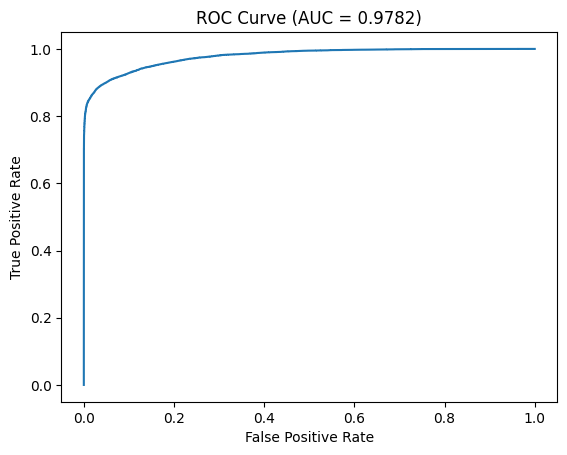

AUC: 0.9781538738256458


In [88]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

print("AUC:", roc_auc)

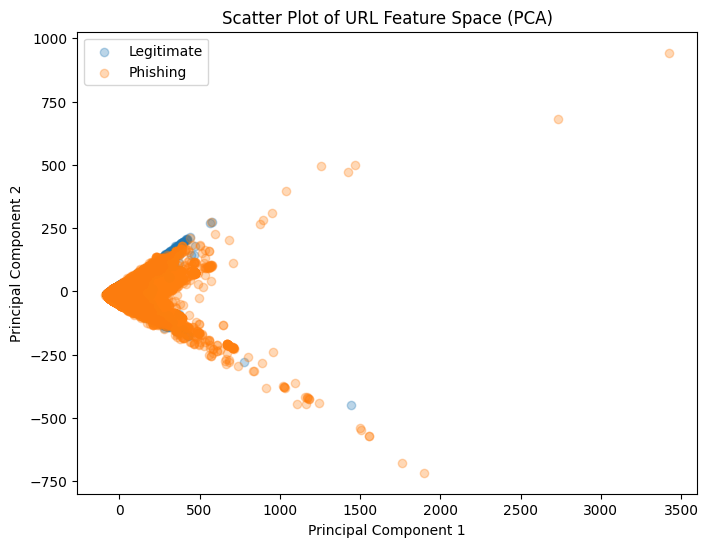

Explained Variance Ratio: [0.85448242 0.10209262]


In [89]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce features to 2 dimensions
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_features)

plt.figure(figsize=(8,6))

# Plot legitimate URLs
plt.scatter(
    X_2d[y_labels == 0, 0],
    X_2d[y_labels == 0, 1],
    alpha=0.3,
    label="Legitimate"
)

# Plot phishing URLs
plt.scatter(
    X_2d[y_labels == 1, 0],
    X_2d[y_labels == 1, 1],
    alpha=0.3,
    label="Phishing"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Scatter Plot of URL Feature Space (PCA)")
plt.legend()
plt.show()

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale only for visualization
scaler_viz = StandardScaler()
X_scaled_viz = scaler_viz.fit_transform(X_features.copy())

# Apply PCA
pca_viz = PCA(n_components=2)
X_2d_viz = pca_viz.fit_transform(X_scaled_viz)

y_viz = y_labels.copy()

In [91]:
from sklearn.ensemble import RandomForestClassifier

model_viz2 = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

model_viz2.fit(X_2d_viz, y_viz)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [92]:
import numpy as np

x_min_v2, x_max_v2 = X_2d_viz[:, 0].min() - 1, X_2d_viz[:, 0].max() + 1
y_min_v2, y_max_v2 = X_2d_viz[:, 1].min() - 1, X_2d_viz[:, 1].max() + 1

xx_v2, yy_v2 = np.meshgrid(
    np.linspace(x_min_v2, x_max_v2, 200),
    np.linspace(y_min_v2, y_max_v2, 200)
)

grid_v2 = np.c_[xx_v2.ravel(), yy_v2.ravel()]
Z_v2 = model_viz2.predict(grid_v2)
Z_v2 = Z_v2.reshape(xx_v2.shape)

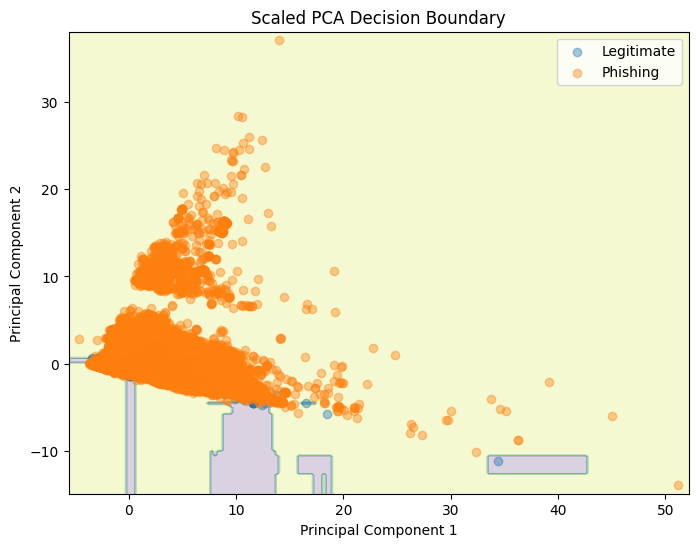

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.contourf(xx_v2, yy_v2, Z_v2, alpha=0.2)

plt.scatter(
    X_2d_viz[y_viz == 0, 0],
    X_2d_viz[y_viz == 0, 1],
    alpha=0.4,
    label="Legitimate"
)

plt.scatter(
    X_2d_viz[y_viz == 1, 0],
    X_2d_viz[y_viz == 1, 1],
    alpha=0.4,
    label="Phishing"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Scaled PCA Decision Boundary")
plt.legend()
plt.show()

In [94]:
joblib.dump(model, "model/phishing_model.pkl")
print("Model saved.")

FileNotFoundError: [Errno 2] No such file or directory: 'model/phishing_model.pkl'

In [ ]:
# Use real trained model
y_real_probs = model.predict_proba(X_features)[:, 1]
y_real_pred = (y_real_probs >= 0.4).astype(int)

# Scale for PCA visualization only
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_real_viz = StandardScaler()
X_scaled_real = scaler_real_viz.fit_transform(X_features)

pca_real_viz = PCA(n_components=2)
X_2d_real = pca_real_viz.fit_transform(X_scaled_real)

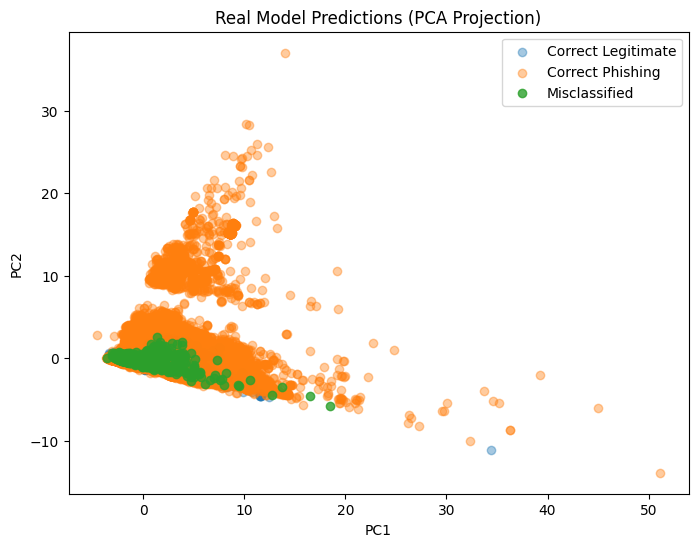

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Correctly predicted legitimate
plt.scatter(
    X_2d_real[(y_labels == 0) & (y_real_pred == 0), 0],
    X_2d_real[(y_labels == 0) & (y_real_pred == 0), 1],
    alpha=0.4,
    label="Correct Legitimate"
)

# Correctly predicted phishing
plt.scatter(
    X_2d_real[(y_labels == 1) & (y_real_pred == 1), 0],
    X_2d_real[(y_labels == 1) & (y_real_pred == 1), 1],
    alpha=0.4,
    label="Correct Phishing"
)

# Misclassified
plt.scatter(
    X_2d_real[y_labels != y_real_pred, 0],
    X_2d_real[y_labels != y_real_pred, 1],
    alpha=0.8,
    label="Misclassified"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Real Model Predictions (PCA Projection)")
plt.legend()
plt.show()

In [ ]:

# False Negatives = phishing predicted as legitimate
false_negatives_mask = (y_labels == 1) & (y_real_pred == 0)

false_negatives = X_features[false_negatives_mask]

print("Number of False Negatives:", false_negatives.shape[0])


Number of False Negatives: 7193


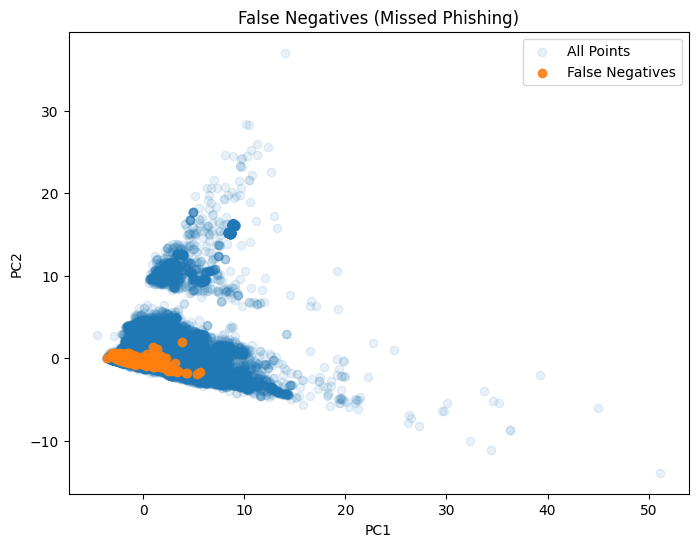

In [ ]:

plt.figure(figsize=(8,6))

plt.scatter(
    X_2d_real[:, 0],
    X_2d_real[:, 1],
    alpha=0.1,
    label="All Points"
)

plt.scatter(
    X_2d_real[false_negatives_mask, 0],
    X_2d_real[false_negatives_mask, 1],
    alpha=0.9,
    label="False Negatives"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("False Negatives (Missed Phishing)")
plt.legend()
plt.show()

In [ ]:

false_negative_urls = df_balanced.loc[false_negatives_mask, "url"].head(20)
false_negative_urls


9                                  registregratuitos.tk/
12                          clinicacodes.com/surpreenda/
31           tiagodesignpa.com.br/teste/images/index.php
33                        base677.s5.com/cgi/aol.base22/
43              politicsintexas.net/~amfaceli/webscr.php
86                                     xzguoyuan.com/js/
153                             ejwall.com.au/Santander/
173                         superganhadorescompreaki.tk/
187    gurumantraseries.com/wp-includes/remax/index.html
237         paseadultomayor.cl/archivos/wowiwo/yahoo.htm
276                 awesomebytes.com/6k/Chase_Online.htm
338                                    lindensurveys.tk/
365               ibadahumroh.com/itau/GRIPNET/index.php
380                                  giftcom.hostzi.com/
421                       ivoire-france.com/us/security/
443        acacomercial.com.br/cp/dispositivo-seguranca/
461       bebel-racing-kart.com/site/images/wuverif.html
491                 terranoracc

In [ ]:
# Get indices of false negatives
fn_indices = df_balanced.index[false_negative_mask]

# Extract those URLs
false_negative_urls = df_balanced.loc[fn_indices, "url"]

# Show first 20
false_negative_urls.head(20)

NameError: name 'false_negative_mask' is not defined

In [4]:
import joblib
import pandas as pd
import shap
import numpy as np

from urllib.parse import urlparse
from feature_extractor import extract_features

# -----------------------------
# Load Saved Objects
# -----------------------------
model = joblib.load("model/phishing_model.pkl")
vectorizer = joblib.load("model/tfidf_vectorizer.pkl")
scaler = joblib.load("model/struct_scaler.pkl")

print("Model loaded.")

# -----------------------------
# Sample URLs to Explain
# -----------------------------
test_urls = [
    "https://secure-paytm-update.com/login",
    "https://www.google.com"
]

# -----------------------------
# Extract Structural Features
# -----------------------------
X_struct = [extract_features(url) for url in test_urls]
X_struct_df = pd.DataFrame(X_struct)

X_struct_scaled = scaler.transform(X_struct_df)

# -----------------------------
# TF-IDF Features
# -----------------------------
X_text = vectorizer.transform(test_urls)

# -----------------------------
# Combine
# -----------------------------
from scipy.sparse import hstack
X_combined = hstack([X_struct_scaled, X_text])

# -----------------------------
# Predict
# -----------------------------
probs = model.predict_proba(X_combined)[:, 1]

for url, prob in zip(test_urls, probs):
    print(f"\nURL: {url}")
    print(f"Phishing Probability: {prob:.4f}")

# -----------------------------
# SHAP Explanation (TreeExplainer)
# -----------------------------
print("\nGenerating SHAP explanation...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_combined)

# Convert sparse to dense for SHAP visualization
X_dense = X_combined.toarray()

# Plot summary
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_dense, show=False)
plt.tight_layout()
plt.savefig("model/shap_summary.png", dpi=300)
print("SHAP summary plot saved to model/shap_summary.png")

FileNotFoundError: [Errno 2] No such file or directory: 'model/phishing_model.pkl'

In [2]:
pip install shap

  Using cached shap-0.50.0-cp312-cp312-win_amd64.whl.metadata (25 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.64.0-cp312-cp312-win_amd64.whl.metadata (3.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached llvmlite-0.46.0-cp312-cp312-win_amd64.whl.metadata (5.1 kB)
Using cached shap-0.50.0-cp312-cp312-win_amd64.whl (549 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numba-0.64.0-cp312-cp312-win_amd64.whl (2.8 MB)
Using cached llvmlite-0.46.0-cp312-cp312-win_amd64.whl (38.1 MB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)

   ----- ---------------------------------- 1/7 [tqdm]
   ----- ---------------------------------- 1/7 [tqdm]